# 파이토치 환경 확인

In [1]:
import torch
print('PyTorch:', torch.__version__)
print('CUDA 사용 가능:', torch.cuda.is_available())
print('GPU:', torch.cuda.get_device_name(0))

PyTorch: 2.6.0+cu124
CUDA 사용 가능: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import ultralytics
ultralytics.checks()

Ultralytics 8.4.31  Python-3.11.15 torch-2.6.0+cu124 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
Setup complete  (16 CPUs, 31.7 GB RAM, 179.3/475.9 GB disk)


In [3]:
import cv2
import ultralytics
import roboflow
import inference_sdk

In [4]:
print("OpenCV:",cv2.__version__)
print("Ultralytics:",ultralytics.__version__)

OpenCV: 4.10.0
Ultralytics: 8.4.31


# 로보플로 인퍼런스 api 사용하기

In [5]:
from inference_sdk import InferenceHTTPClient
#연결 클라이언트 생성
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="LaWj9rQesdm9r5Exp4ea"
)
#추론 요청하기
result = CLIENT.infer('sample.jpg', model_id="rock-paper-scissors-sxsw/14")
result

{'inference_id': '3b400f48-fc55-4f43-935f-1792140f9b3e',
 'time': 0.009739791043102741,
 'image': {'width': 199, 'height': 254},
 'predictions': [{'x': 149.5,
   'y': 123.0,
   'width': 41.0,
   'height': 50.0,
   'confidence': 0.8397936224937439,
   'class': 'Rock',
   'class_id': 1,
   'detection_id': '98cab89b-b999-4e04-82aa-eeaa6464b257'},
  {'x': 55.5,
   'y': 127.5,
   'width': 107.0,
   'height': 51.0,
   'confidence': 0.7701728343963623,
   'class': 'Scissors',
   'class_id': 2,
   'detection_id': '235e4899-01b1-43f5-b04a-ed08098bb14d'},
  {'x': 144.0,
   'y': 186.0,
   'width': 40.0,
   'height': 60.0,
   'confidence': 0.4639713764190674,
   'class': 'Rock',
   'class_id': 1,
   'detection_id': '949ad9e0-a285-40ea-853a-8324d0722c06'}]}

# 이미지 시각화

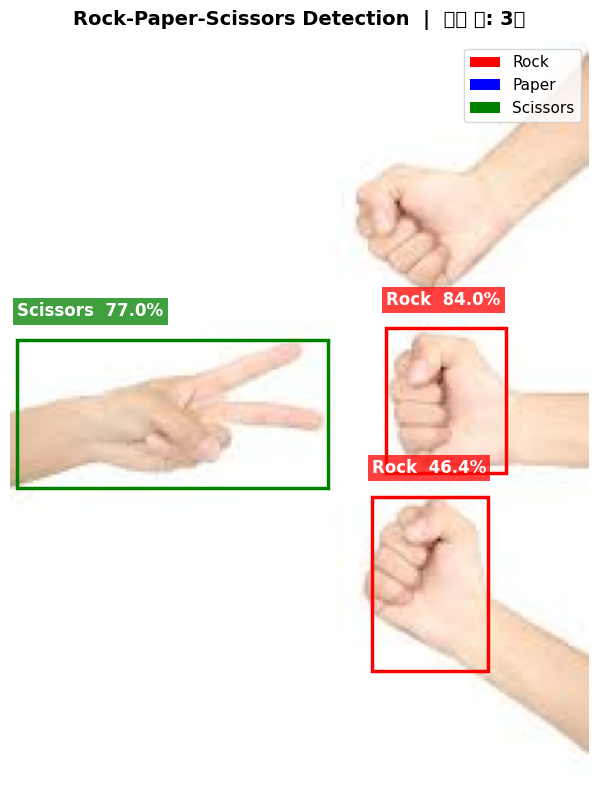


📦 감지된 객체 수: 3개
  [1] Rock       | 신뢰도: 84.0%  |  중심: (150, 123)  |  크기: 41×50
  [2] Scissors   | 신뢰도: 77.0%  |  중심: (56, 128)  |  크기: 107×51
  [3] Rock       | 신뢰도: 46.4%  |  중심: (144, 186)  |  크기: 40×60


In [6]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ============================================================
# 클래스별 색상 지정
# ============================================================
COLOR_MAP = {
    "Rock"     : "red",
    "Paper"    : "blue",
    "Scissors" : "green",
}

# ============================================================
# 이미지 로드
# ============================================================
img       = Image.open("sample.jpg").convert("RGB")
img_array = np.array(img)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img_array)

# ============================================================
# 바운딩 박스 그리기
# ============================================================
predictions = result.get("predictions", [])

for det in predictions:
    # Roboflow → 중심 좌표(cx, cy) + width, height
    cx         = det["x"]
    cy         = det["y"]
    w          = det["width"]
    h          = det["height"]
    label      = det["class"]
    confidence = det["confidence"]

    # 좌상단 좌표로 변환
    x1 = cx - w / 2
    y1 = cy - h / 2

    color = COLOR_MAP.get(label, "yellow")

    # 사각형 박스
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2.5,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    # 레이블 + 신뢰도 텍스트
    ax.text(
        x1, y1 - 8,
        f"{label}  {confidence*100:.1f}%",
        color="white",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor=color, alpha=0.75, pad=3, edgecolor="none")
    )

# ============================================================
# 범례 & 타이틀
# ============================================================
legend_elements = [
    patches.Patch(facecolor="red",   label="Rock"),
    patches.Patch(facecolor="blue",  label="Paper"),
    patches.Patch(facecolor="green", label="Scissors"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

ax.set_title(
    f"Rock-Paper-Scissors Detection  |  감지 수: {len(predictions)}개",
    fontsize=14, fontweight="bold", pad=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rps_result.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 콘솔 출력
# ============================================================
print(f"\n📦 감지된 객체 수: {len(predictions)}개")
for i, det in enumerate(predictions, 1):
    print(f"  [{i}] {det['class']:10s} | 신뢰도: {det['confidence']*100:.1f}%"
          f"  |  중심: ({det['x']:.0f}, {det['y']:.0f})"
          f"  |  크기: {det['width']:.0f}×{det['height']:.0f}")


In [7]:
from inference_sdk import InferenceHTTPClient
#연결 클라이언트 생성
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="LaWj9rQesdm9r5Exp4ea"
)
#추론 요청하기
result = CLIENT.infer('sample1.jpg', model_id="rock-paper-scissors-sxsw/14")
result

{'inference_id': '525ea6ef-b73c-4442-a570-657a555aa1b2',
 'time': 0.008041705004870892,
 'image': {'width': 299, 'height': 168},
 'predictions': []}

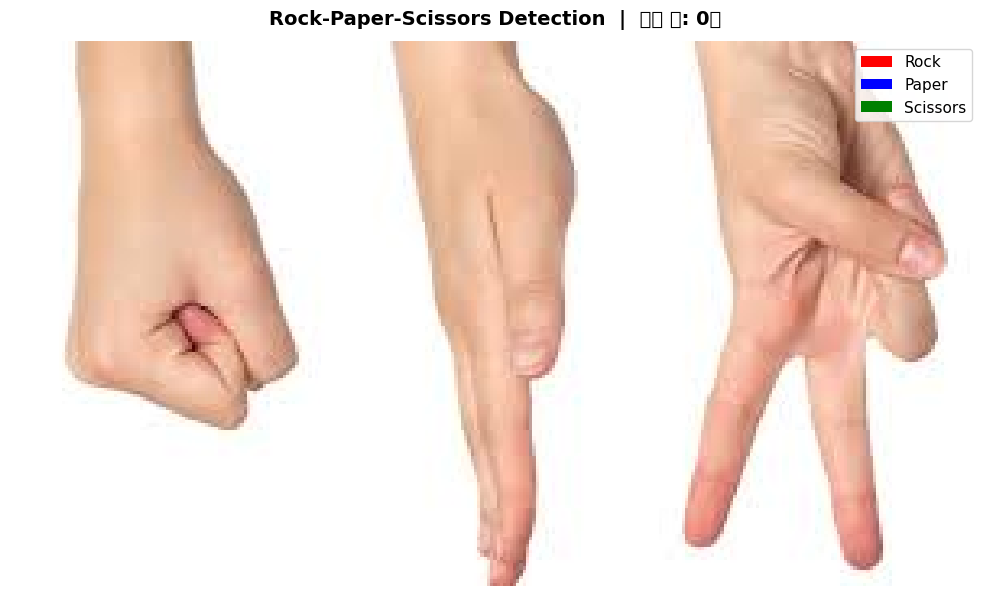


📦 감지된 객체 수: 0개


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ============================================================
# 클래스별 색상 지정
# ============================================================
COLOR_MAP = {
    "Rock"     : "red",
    "Paper"    : "blue",
    "Scissors" : "green",
}

# ============================================================
# 이미지 로드
# ============================================================
img       = Image.open("sample1.jpg").convert("RGB")
img_array = np.array(img)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img_array)

# ============================================================
# 바운딩 박스 그리기
# ============================================================
predictions = result.get("predictions", [])

for det in predictions:
    # Roboflow → 중심 좌표(cx, cy) + width, height
    cx         = det["x"]
    cy         = det["y"]
    w          = det["width"]
    h          = det["height"]
    label      = det["class"]
    confidence = det["confidence"]

    # 좌상단 좌표로 변환
    x1 = cx - w / 2
    y1 = cy - h / 2

    color = COLOR_MAP.get(label, "yellow")

    # 사각형 박스
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2.5,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    # 레이블 + 신뢰도 텍스트
    ax.text(
        x1, y1 - 8,
        f"{label}  {confidence*100:.1f}%",
        color="white",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor=color, alpha=0.75, pad=3, edgecolor="none")
    )

# ============================================================
# 범례 & 타이틀
# ============================================================
legend_elements = [
    patches.Patch(facecolor="red",   label="Rock"),
    patches.Patch(facecolor="blue",  label="Paper"),
    patches.Patch(facecolor="green", label="Scissors"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

ax.set_title(
    f"Rock-Paper-Scissors Detection  |  감지 수: {len(predictions)}개",
    fontsize=14, fontweight="bold", pad=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rps_result.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 콘솔 출력
# ============================================================
print(f"\n📦 감지된 객체 수: {len(predictions)}개")
for i, det in enumerate(predictions, 1):
    print(f"  [{i}] {det['class']:10s} | 신뢰도: {det['confidence']*100:.1f}%"
          f"  |  중심: ({det['x']:.0f}, {det['y']:.0f})"
          f"  |  크기: {det['width']:.0f}×{det['height']:.0f}")


In [10]:
from inference_sdk import InferenceHTTPClient
#연결 클라이언트 생성
CLIENT = InferenceHTTPClient(
    api_url="https://serverless.roboflow.com",
    api_key="LaWj9rQesdm9r5Exp4ea"
)
#추론 요청하기
result = CLIENT.infer('sample2.png', model_id="rock-paper-scissors-sxsw/14")
result

{'inference_id': 'c2609426-2840-4a3d-aa7f-c1e85a5107f1',
 'time': 0.014955204911530018,
 'image': {'width': 651, 'height': 460},
 'predictions': [{'x': 306.0,
   'y': 180.0,
   'width': 94.0,
   'height': 114.0,
   'confidence': 0.46027350425720215,
   'class': 'Rock',
   'class_id': 1,
   'detection_id': '74eb77e9-cc64-4732-968a-8ad43c279bb0'}]}

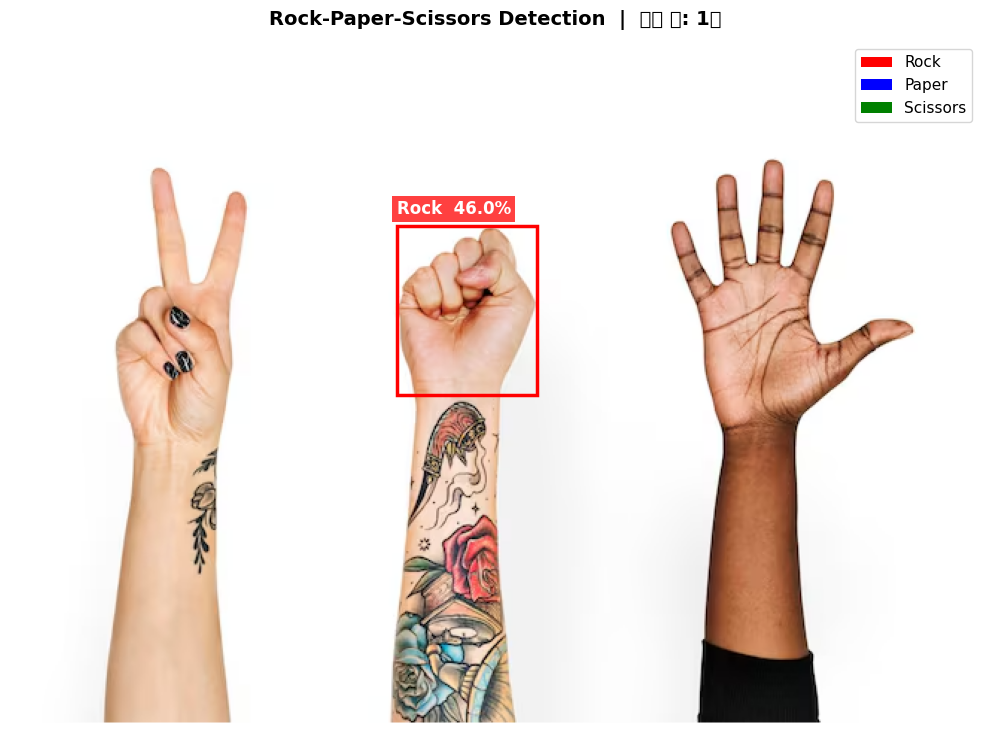


📦 감지된 객체 수: 1개
  [1] Rock       | 신뢰도: 46.0%  |  중심: (306, 180)  |  크기: 94×114


In [11]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import numpy as np

# ============================================================
# 클래스별 색상 지정
# ============================================================
COLOR_MAP = {
    "Rock"     : "red",
    "Paper"    : "blue",
    "Scissors" : "green",
}

# ============================================================
# 이미지 로드
# ============================================================
img       = Image.open("sample2.png").convert("RGB")
img_array = np.array(img)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
ax.imshow(img_array)

# ============================================================
# 바운딩 박스 그리기
# ============================================================
predictions = result.get("predictions", [])

for det in predictions:
    # Roboflow → 중심 좌표(cx, cy) + width, height
    cx         = det["x"]
    cy         = det["y"]
    w          = det["width"]
    h          = det["height"]
    label      = det["class"]
    confidence = det["confidence"]

    # 좌상단 좌표로 변환
    x1 = cx - w / 2
    y1 = cy - h / 2

    color = COLOR_MAP.get(label, "yellow")

    # 사각형 박스
    rect = patches.Rectangle(
        (x1, y1), w, h,
        linewidth=2.5,
        edgecolor=color,
        facecolor="none"
    )
    ax.add_patch(rect)

    # 레이블 + 신뢰도 텍스트
    ax.text(
        x1, y1 - 8,
        f"{label}  {confidence*100:.1f}%",
        color="white",
        fontsize=12,
        fontweight="bold",
        bbox=dict(facecolor=color, alpha=0.75, pad=3, edgecolor="none")
    )

# ============================================================
# 범례 & 타이틀
# ============================================================
legend_elements = [
    patches.Patch(facecolor="red",   label="Rock"),
    patches.Patch(facecolor="blue",  label="Paper"),
    patches.Patch(facecolor="green", label="Scissors"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=11)

ax.set_title(
    f"Rock-Paper-Scissors Detection  |  감지 수: {len(predictions)}개",
    fontsize=14, fontweight="bold", pad=12
)
ax.axis("off")
plt.tight_layout()
plt.savefig("rps_result.png", dpi=150, bbox_inches="tight")
plt.show()

# ============================================================
# 콘솔 출력
# ============================================================
print(f"\n📦 감지된 객체 수: {len(predictions)}개")
for i, det in enumerate(predictions, 1):
    print(f"  [{i}] {det['class']:10s} | 신뢰도: {det['confidence']*100:.1f}%"
          f"  |  중심: ({det['x']:.0f}, {det['y']:.0f})"
          f"  |  크기: {det['width']:.0f}×{det['height']:.0f}")
